# ErrorGnomark Tutorial: Benchmarking Quantum Gates with XEB

Welcome to the ErrorGnomark tutorial! In this guide, we will demonstrate how to use Cross-Entropy Benchmarking (XEB) to precisely measure and characterize the error rates of quantum gates. This tutorial is designed to be run step-by-step, like a Jupyter Notebook.

We will cover three core use cases:
1.  **Single-Qubit XEB Fit**: Measure the average error of random gates applied to a single qubit.
2.  **Two-Qubit XEB Fit**: Isolate and measure the error of a specific two-qubit gate (CZ).
3.  **Multi-Qubit Fidelity Estimation**: Perform a single fidelity measurement on a larger, randomly generated multi-qubit circuit.

In [2]:
# CELL 1: SETUP AND IMPORTS
# First, we import all necessary modules. This includes our simulator backend,
# XEB experiment classes, analysis tools, and the plotting library.
# We also configure the system path to ensure the errorgnomark library is found.

import os
import sys
import matplotlib.pyplot as plt


# Import the necessary classes from our library
from errorgnomark.backends.dummy_backend import DummyBackend
from errorgnomark.experiments.benchmarking.xeb import (
    SingleQubitGateError,
    TwoQubitGateError,
    StandardXEBInstance
)
from errorgnomark.analysis.benchmarking.xeb_analysis import plot_xeb_fit
# This import ensures all built-in gate sets are registered
from errorgnomark.experiments import gate_sets

print("Environment setup complete. All modules imported successfully.")

Environment setup complete. All modules imported successfully.


### Step 2: Configuration

Next, we define the parameters for our simulation and experiments. This includes the noise level of our simulated quantum computer, the circuit depths for the fitting experiments, and the number of measurements (shots).

- **`SHARED_BACKEND_CONFIG`**: We will use a `DummyBackend` with a uniform depolarizing error of 0.5% for all gates. Our backward-compatible backend will correctly interpret this.
- **`CORRECT_GATE_SET_FOR_XEB`**: We use the `"universal_xeb"` gate set. This is crucial as it generates the random unitary gates required for a physically meaningful XEB experiment.

In [3]:
# CELL 2: CONFIGURATION
# Here we define the parameters that will be used across all experiments.

# Backend noise level
SHARED_BACKEND_CONFIG = {"depolarizing_error": 0.01}

# Parameters for fitting experiments (Cases 1 & 2)
DEPTHS_FOR_FITTING = [1, 2, 10, 25, 50]
NUM_CIRCUITS_PER_DEPTH = 100
SHOTS = 100000

# The correct gate set that generates random unitaries as matrices.
CORRECT_GATE_SET_FOR_XEB = "universal_xeb"

# Parameters for specific cases
QUBIT_1Q_TEST = [0]
PAIR_2Q_TEST = [(0, 1)]
QUBITS_MULTI_TEST = list(range(5))

# --- Initialize the shared backend ---
# This backend will be used for all three cases.
shared_backend = DummyBackend(**SHARED_BACKEND_CONFIG)

print(f" Backend configured: {type(shared_backend).__name__}")
print(f"   - 1Q Depolarizing Error: {shared_backend.depolarizing_error_1q:.4f}")
print(f"   - 2Q Depolarizing Error: {shared_backend.depolarizing_error_2q:.4f}")

 Backend configured: DummyBackend
   - 1Q Depolarizing Error: 0.0100
   - 2Q Depolarizing Error: 0.0100


/var/folders/_c/1xxr2vwx3kg_3b3ws0_kr9p80000gn/T/ipykernel_52968/3896728088.py:22: DeprecationWarning: 'depolarizing_error' is a legacy parameter. It is being applied to both 'depolarizing_error_1q' and 'depolarizing_error_2q'. For more precise control, please use the new parameters.
  shared_backend = DummyBackend(**SHARED_BACKEND_CONFIG)


### Case 1: Single-Qubit Average Gate Error Estimation

Our first task is to measure the average error rate of single-qubit gates. The `SingleQubitGateError` experiment automates this process. It generates random single-qubit circuits of varying depths, runs them on the backend, calculates the fidelity for each, and then fits an exponential decay curve to the results. The decay rate of this curve gives us the error per gate.


CASE 1: Fitting Average 1Q Gate Error (from Universal XEB set)
----------------------------------------------------------------------
--- Starting Single-Qubit Gate Error Estimation for qubits [0] ---

Estimating error for qubit 0...
  Running depth 1 (100 circuits)...
  Running depth 2 (100 circuits)...
  Running depth 10 (100 circuits)...
  Running depth 25 (100 circuits)...
  Running depth 50 (100 circuits)...
Fitting decay curve for qubit 0...

  > Final Result for Qubit 0:
    - Estimated Average 1Q Gate Error: 0.000603 (0.0603%)


<Figure size 640x480 with 0 Axes>

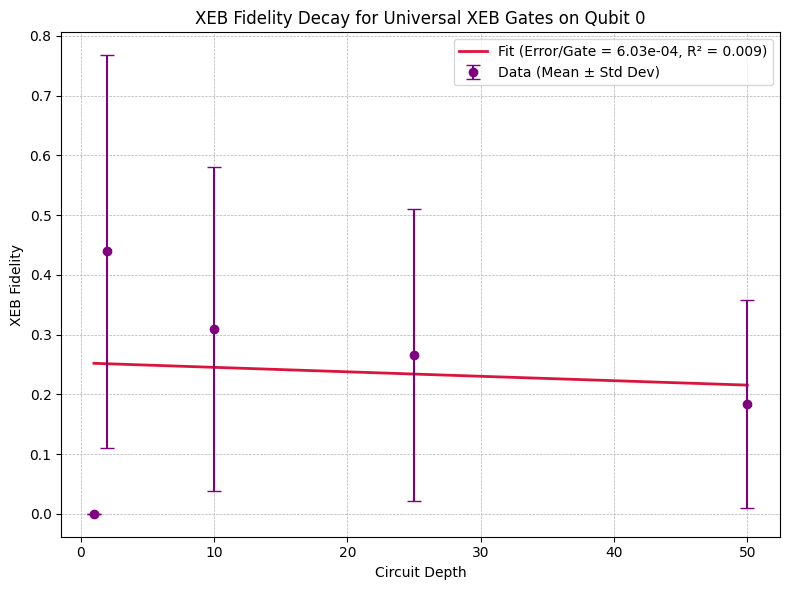


Case 1 Complete.


In [4]:
# CELL 3: RUNNING CASE 1 (1Q XEB FIT)

print("\nCASE 1: Fitting Average 1Q Gate Error (from Universal XEB set)")
print("-" * 70)

# 1. Initialize the experiment estimator
single_q_estimator = SingleQubitGateError(
    qubits_to_test=QUBIT_1Q_TEST,
    depths=DEPTHS_FOR_FITTING,
    num_circuits=NUM_CIRCUITS_PER_DEPTH,
    gate_set=CORRECT_GATE_SET_FOR_XEB,
    backend=shared_backend,
    verbose=True
)

# 2. Run the experiment and get detailed results
single_q_results = single_q_estimator.run_and_fit(shots=SHOTS, return_detailed=True)

# 3. Process and display the results
for qubit, data in single_q_results.items():
    error = data['fit_results'].get('error_per_gate', float('nan'))
    print(f"\n  > Final Result for Qubit {qubit}:")
    print(f"    - Estimated Average 1Q Gate Error: {error:.6f} ({error*100:.4f}%)")

    # 4. Plot the fit
    plt.figure("Figure 1: 1Q Gate Error Fit (Universal XEB Set)")
    plot_xeb_fit(
        fidelities=data['raw_fidelities'],
        fit_results=data['fit_results'],
        title_info=f"for Universal XEB Gates on Qubit {qubit}"
    )
print("\nCase 1 Complete.")

### Case 2: Two-Qubit Specific Gate (CZ) Error Estimation

Now, we'll measure the error of a specific two-qubit gate, the `CZ` gate. The `TwoQubitGateError` experiment is designed for this. It constructs circuits that alternate between layers of random single-qubit gates (to scramble the state) and a layer containing our `target_gate`. By measuring the fidelity decay as a function of the number of `CZ` layers, we can isolate and estimate the error of the `CZ` gate itself.

In [5]:
# CELL 4: RUNNING CASE 2 (2Q XEB FIT)

print("\n\nCASE 2: Fitting Specific 2Q Gate Error (CZ) with Universal 1Q gates")
print("-" * 70)

# 1. Initialize the experiment estimator, specifying the target gate
cz_estimator = TwoQubitGateError(
    pairs_to_test=PAIR_2Q_TEST,
    depths=DEPTHS_FOR_FITTING,
    num_circuits=NUM_CIRCUITS_PER_DEPTH,
    gate_set=CORRECT_GATE_SET_FOR_XEB,
    target_gate='cz',  # <-- This is the key parameter
    backend=shared_backend,
    verbose=True
)

# 2. Run the experiment
cz_results = cz_estimator.run_and_fit(shots=SHOTS, return_detailed=True)

# 3. Process and display the results
for pair, data in cz_results.items():
    error = data['fit_results'].get('error_per_gate', float('nan'))
    print(f"\n  > Final Result for Pair {pair} (CZ Gate):")
    print(f"    - Estimated CZ Gate Error: {error:.6f} ({error*100:.4f}%)")

    # # 4. Plot the fit
    # plt.figure("Figure 2: 2Q Gate Error Fit (Universal XEB + CZ)")
    # plot_xeb_fit(
    #     fidelities=data['raw_fidelities'],
    #     fit_results=data['fit_results'],
    #     title_info=f"for CZ Gate (with XEB layers) on Pair {pair}"
    # )
print("\n Case 2 Complete.")



CASE 2: Fitting Specific 2Q Gate Error (CZ) with Universal 1Q gates
----------------------------------------------------------------------
--- Starting Two-Qubit Gate Error Estimation for pairs [(0, 1)] ---
--- Target 2Q Gate: 'CZ' ---
  > Overriding gate set's default 2Q gate ('CZ') with 'CZ'.

Estimating error for pair (0, 1)...
  Running depth 1 (100 circuits)...
  Running depth 2 (100 circuits)...
  Running depth 10 (100 circuits)...
  Running depth 25 (100 circuits)...
  Running depth 50 (100 circuits)...
Fitting decay curve for pair (0, 1)...

  > Final Result for Pair (0, 1) (CZ Gate):
    - Estimated CZ Gate Error: 0.000060 (0.0060%)

 Case 2 Complete.


### Case 3: Multi-Qubit Single Instance Fidelity Measurement

Finally, let's measure the fidelity of a single, larger quantum circuit. Instead of fitting a decay curve, we will use the `StandardXEBInstance` to create one random 5-qubit circuit and measure its fidelity. This is useful for quickly assessing the performance of a specific circuit or for holistic benchmarking of a multi-qubit system.

In [6]:
# CELL 5: RUNNING CASE 3 (5Q SINGLE FIDELITY)

print("\n\nCASE 3: Measuring Single Fidelity for a 5-Qubit Circuit (Universal XEB)")
print("-" * 70)

print(f"  > Creating a single random circuit for {len(QUBITS_MULTI_TEST)} qubits...")

# 1. Initialize a single XEB task
multi_qubit_instance = StandardXEBInstance(
    qubits=QUBITS_MULTI_TEST,
    depth=20,  # A moderate depth for a 5-qubit circuit
    gate_set=CORRECT_GATE_SET_FOR_XEB,
    backend=shared_backend
)

# 2. Run the single instance to get its fidelity
final_fidelity = multi_qubit_instance.run(shots=SHOTS)

# 3. Print the result
print("\n  > Final Result:")
print(f"    - Measured XEB Fidelity for the 5-Qubit Circuit: {final_fidelity:.6f}")
print("\n Case 3 Complete.")



CASE 3: Measuring Single Fidelity for a 5-Qubit Circuit (Universal XEB)
----------------------------------------------------------------------
  > Creating a single random circuit for 5 qubits...

  > Final Result:
    - Measured XEB Fidelity for the 5-Qubit Circuit: 0.030479

 Case 3 Complete.


### Tutorial Complete

You have successfully run all three benchmarking demonstrations! The generated plots show the fidelity decay and the fitted error rates. You can now close the plot windows to exit the program.